# Label extraction

### Introduction

We don't need perfect labels here. The image model will train on ~4,349 LLM-pseudo-labeled studies, and deep nets tolerate a surprising amount of label noise without a comparable drop in test performance *as long as the noise is unbiased* (random misses that vary case-by-case, not a consistent skew in one direction). What actually caps downstream performance is **systematic** bias: a condition the labeler consistently over or under-calls. Section 2 below checks both the overall agreement rate and, specifically, whether any condition's errors are directionally biased rather than random.

### Contents

- **Calibration review** how well does the labeler agree with the 58 gold rows?
- **Pseudo-labeled dataset QA** QA of the fully-labeled dataset the Luigi pipeline produces.

### Reading list

- Rolnick, Veit, Belongie & Shavit (2017), ["Deep Learning is Robust to Massive Label Noise"](https://arxiv.org/abs/1711.10370): CNNs tolerate very high noise-to-signal ratios given enough data; *random* noise is far less damaging than *systematic* noise.
- Zhang, Bengio, Hardt, Recht & Vinyals (2017), ["Understanding Deep Learning Requires Rethinking Generalization"](https://arxiv.org/pdf/1611.03530) (ICLR): deep nets can memorize pure random labels, so robustness isn't unconditional; there must be real signal to lock onto alongside the noise.
- Patrini, Rozza, Krishna Menon, Nock & Qu (2017), ["Making Deep Neural Networks Robust to Label Noise: A Loss Correction Approach"](https://arxiv.org/pdf/1609.03683) (CVPR): loss-correction methods for when the noise transition matrix (i.e. directional bias) is known or estimable.
- Natarajan, Dhillon, Ravikumar & Tewari (2013), ["Learning with Noisy Labels"](https://proceedings.neurips.cc/paper_files/paper/2013/file/3871bd64012152bfb53fdf04b401193f-Paper.pdf) (NeurIPS): theoretical foundation for risk-consistent learning under class-conditional (asymmetric) label noise.
- Song, Kim, Park, Shin & Lee (2022), ["Learning from Noisy Labels with Deep Neural Networks: A Survey"](https://arxiv.org/pdf/2007.08199) (IEEE TNNLS): broad survey tying the above together.


## 1. Notebook setup

### 1.1. Imports

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score
from statsmodels.stats.contingency_tables import mcnemar

import configuration as config
import data_pipeline.label_extraction.config as pipeline_config # noqa: E402

### 1.2. Configuration

In [2]:
CALIBRATION_RUN = '20260905_001'
LABEL_RUN       = '20260909_001'

## 2. Calibration review

### 2.1. Load and parse calibration data

In [3]:
# Load cached calibration rows and gold labels
cal_dir = Path('../data/pipeline/label_extraction') / CALIBRATION_RUN / 'calibration_rows'
raw = pd.read_csv(config.TRAIN_CSV)

label_cols = [c for c in raw.columns if c not in ('StudyInstanceUID', 'Report')]
gold_mask = raw[label_cols].notna().any(axis=1)
gold = raw[gold_mask].set_index('StudyInstanceUID')
files = sorted(cal_dir.glob('*.json'))

print(f'{len(files)} labeled calibration rows vs {len(gold)} gold rows')

58 labeled calibration rows vs 58 gold rows


In [4]:
# Load per-UID calibration predictions: each file is a dict of
# condition -> [value, evidence], keyed by the UID (filename stem).
rows = []

for f in files:
    uid = f.stem
    pred = json.loads(f.read_text())
    rec = {'StudyInstanceUID': uid}

    for c in label_cols:
        v, _ev = pred.get(c, [0, ''])
        rec[c] = v

    rows.append(rec)

preds = pd.DataFrame(rows).set_index('StudyInstanceUID').loc[gold.index]
cmp_df = gold.join(preds, lsuffix='_label', rsuffix='_pred')
cmp_df.head()

,Report,ACL_label,MCL_label,Medial Meniscus_label,Lateral Meniscus_label,Medial OA_label,Lateral OA_label,PF OA_label,Effusion_label,Synovitis_label,...,Medial Meniscus_pred,Lateral Meniscus_pred,Medial OA_pred,Lateral OA_pred,PF OA_pred,Effusion_pred,Synovitis_pred,Baker's_pred,Contusion_pred,Fracture_pred
StudyInstanceUID,,,,,,,,,,,,,,,,,,,,,
1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149,Antecedentes Clínicos:\nEsguince rodilla. [DAT...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0,1,0,0,1,1,0,0,0,0
1.2.826.0.1.3680043.8.498.10170898615867673028696505248839028269,The study reveals normal knee joint alignment...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0,1,0,0,1,1,1,0,0,1
1.2.826.0.1.3680043.8.498.10306159113324811538703788080836752052,Exam Type: MRI KNEE RIGHT WO CONTRAST\nExam Da...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1,0,1,1,1,1,0,0,0,0
1.2.826.0.1.3680043.8.498.11287937729196958426538087439102017580,"MRI of left Knee with \n-3-Plane Loc R'T, Sag ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,1,1,0,0,0
1.2.826.0.1.3680043.8.498.11382021393803389951964005983002209238,"In the medial compartment, there is longitudi...",1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0,0,0,0,0,0,0,0


### 2.2. Score predictions

In [5]:
def kappa(g, p):
    '''Cohen's kappa.'''

    g, p = np.asarray(g), np.asarray(p)
    po = (g == p).mean()
    pg = g.mean(); pp = p.mean()
    pe = pg * pp + (1 - pg) * (1 - pp)

    return (po - pe) / (1 - pe) if pe < 1 else 1.0

In [6]:
recs = []

for c in label_cols:
    g = (cmp_df[f'{c}_label'].fillna(0) == 1).astype(int).values
    p = (cmp_df[f'{c}_pred'].fillna(0) == 1).astype(int).values

    recs.append({
        'condition': c,
        'gold_pos': int(g.sum()),
        'pred_pos': int(p.sum()),
        'accuracy': float((g == p).mean()),
        'kappa': kappa(g, p),
        'false_neg': int(((g == 1) & (p == 0)).sum()),
        'false_pos': int(((g == 0) & (p == 1)).sum()),
    })

cmp_tbl = pd.DataFrame(recs).set_index('condition')
cmp_tbl['accuracy'] = cmp_tbl['accuracy'].map('{:.3f}'.format)
cmp_tbl['kappa'] = cmp_tbl['kappa'].map('{:.3f}'.format)

print(
    'Mean accuracy:', round(cmp_tbl['accuracy'].astype(float).mean(), 3),
    '| Mean kappa:', round(cmp_tbl['kappa'].astype(float).mean(), 3)
)

cmp_tbl

Mean accuracy: 0.816 | Mean kappa: 0.587


,gold_pos,pred_pos,accuracy,kappa,false_neg,false_pos
condition,,,,,,
ACL,24,33,0.845,0.697,0,9
MCL,9,18,0.845,0.580,0,9
Medial Meniscus,26,28,0.862,0.723,3,5
Lateral Meniscus,23,23,0.828,0.640,5,5
Medial OA,15,19,0.897,0.752,1,5
Lateral OA,11,16,0.845,0.570,2,7
PF OA,21,25,0.793,0.570,4,8
Effusion,35,51,0.724,0.346,0,16
Synovitis,27,17,0.690,0.361,14,4


### 2.3. Confusion matrices (per condition)

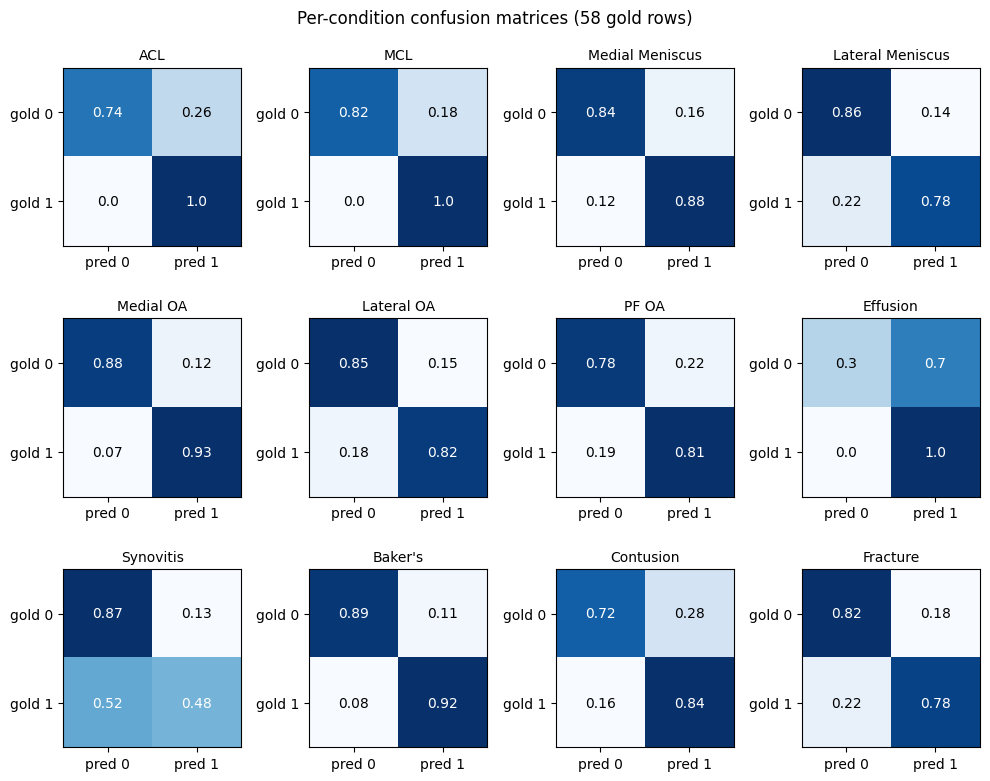

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax, c in zip(axes.flat, label_cols):
    g = (cmp_df[f'{c}_label'].fillna(0) == 1).astype(int).values
    p = (cmp_df[f'{c}_pred'].fillna(0) == 1).astype(int).values
    cm = confusion_matrix(g, p, labels=[0, 1], normalize='true')

    ax.imshow(cm, cmap='Blues')
    ax.set_title(c, fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['pred 0', 'pred 1'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['gold 0', 'gold 1'])

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, round(cm[i, j], 2), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black'
            )

fig.suptitle('Per-condition confusion matrices (58 gold rows)')
fig.tight_layout()
plt.show()

### 2.4 Average AUC

**Caveat:** the labeler emits a hard 0/1 vote per condition, not a probability, so `roc_auc_score`/`average_precision_score` below are computed on binary scores. That collapses ROC AUC to `0.5 * (TPR + TNR)` (balanced accuracy) rather than a true ranking-based AUC, and it is measured against only 58 gold *report-text* rows. It is **not directly comparable** to a competition leaderboard AUC, which is computed from a continuous-probability *image* model scored against a much larger test set. Treat this as a sanity-check floor on label quality, not a proxy for achievable leaderboard score.

In [8]:
roc_aucs, pr_aps = {}, {}

for c in label_cols:
    g = (cmp_df[f'{c}_label'].fillna(0) == 1).astype(int).values
    p = (cmp_df[f'{c}_pred'].fillna(0) == 1).astype(int).values

    roc_aucs[c] = roc_auc_score(g, p)
    pr_aps[c] = average_precision_score(g, p)

mean_roc_auc = float(np.mean(list(roc_aucs.values())))
mean_ap = float(np.mean(list(pr_aps.values())))

print(f'Macro-average ROC AUC across {len(label_cols)} conditions: {mean_roc_auc:.3f}')
print(f'Macro-average PR AUC (avg. precision) across {len(label_cols)} conditions: {mean_ap:.3f}')

pd.DataFrame({'roc_auc': roc_aucs, 'avg_precision': pr_aps}).round(3).sort_values('roc_auc')

Macro-average ROC AUC across 12 conditions: 0.818
Macro-average PR AUC (avg. precision) across 12 conditions: 0.634


,roc_auc,avg_precision
Effusion,0.652,0.686
Synovitis,0.676,0.610
Contusion,0.780,0.551
PF OA,0.797,0.619
Fracture,0.801,0.587
Lateral Meniscus,0.820,0.699
Lateral OA,0.835,0.495
Medial Meniscus,0.864,0.778
ACL,0.868,0.727
Baker's,0.904,0.647


### 2.5. Directional bias check

[McNemars's exact test](https://en.wikipedia.org/wiki/McNemar%27s_test)

Gold and the LLM are two paired raters scoring the same 58 studies. Random disagreements (sometimes gold-only, sometimes LLM-only, roughly balanced) tend to average out during downstream training. Systematic bias (e.g. "the LLM almost always calls this condition when gold doesn't") does not; it teaches the image model a consistent skew. McNemar's exact test is the standard test for exactly this paired-rater setup: it checks, per condition, whether the two types of discordant pairs (gold=0/LLM=1 vs gold=1/LLM=0) are significantly different from a 50/50 split; a small p-value with a lopsided ratio flags directional bias rather than noise.

In [9]:
bias_recs = []

for c in label_cols:
    g = (cmp_df[f'{c}_label'].fillna(0) == 1).astype(int).values
    p = (cmp_df[f'{c}_pred'].fillna(0) == 1).astype(int).values

    false_pos = int(((g == 0) & (p == 1)).sum())  # labeler over-calls
    false_neg = int(((g == 1) & (p == 0)).sum())  # labeler under-calls
    n_discordant = false_pos + false_neg

    # McNemar table: rows/cols don't matter here, only the off-diagonal (discordant) counts.
    table = [[0, false_neg], [false_pos, 0]]
    pvalue = mcnemar(table, exact=True).pvalue if n_discordant > 0 else float('nan')

    bias_recs.append({
        'condition': c,
        'false_pos': false_pos,
        'false_neg': false_neg,
        'n_discordant': n_discordant,
        'bias_direction': 'over-calls' if false_pos > false_neg else ('under-calls' if false_neg > false_pos else 'balanced'),
        'mcnemar_p': pvalue,
    })

bias_tbl = pd.DataFrame(bias_recs).set_index('condition').sort_values('mcnemar_p')
bias_tbl['flag'] = np.where(bias_tbl['mcnemar_p'] < 0.05, '*** significant bias ***', '')
bias_tbl

,false_pos,false_neg,n_discordant,bias_direction,mcnemar_p,flag
condition,,,,,,
Effusion,16,0,16,over-calls,0.000031,*** significant bias ***
ACL,9,0,9,over-calls,0.003906,*** significant bias ***
MCL,9,0,9,over-calls,0.003906,*** significant bias ***
Synovitis,4,14,18,under-calls,0.030884,*** significant bias ***
Contusion,11,3,14,over-calls,0.057373,
Lateral OA,7,2,9,over-calls,0.179688,
Medial OA,5,1,6,over-calls,0.218750,
Baker's,5,1,6,over-calls,0.218750,
PF OA,8,4,12,over-calls,0.387695,


In [10]:
# Mismatches per condition (condition = the condition you want to audit)
for cond in ['Effusion', 'Synovitis', 'Contusion']:
    g = (cmp_df[f'{cond}_label'].fillna(0) == 1).astype(int).values
    p = (cmp_df[f'{cond}_pred'].fillna(0) == 1).astype(int).values

    mm = cmp_df[(g == 1) & (p == 0) | (g == 0) & (p == 1)].copy()

    mm['gold'] = mm[f'{cond}_label'].fillna(0).astype(int)
    mm['pred'] = mm[f'{cond}_pred'].fillna(0).astype(int)
    mm['type'] = np.where((mm['gold'] == 1) & (mm['pred'] == 0), 'missed', 'false')

    print(f'{cond}: {len(mm)} mismatches -> {dict(mm["type"].value_counts())}')
    display(mm[['gold', 'pred', 'type']])

Effusion: 16 mismatches -> {'false': np.int64(16)}


,gold,pred,type
StudyInstanceUID,,,
1.2.826.0.1.3680043.8.498.10170898615867673028696505248839028269,0,1,false
1.2.826.0.1.3680043.8.498.10306159113324811538703788080836752052,0,1,false
1.2.826.0.1.3680043.8.498.11771393824519892797114773408583976756,0,1,false
1.2.826.0.1.3680043.8.498.12978510157202852202776899910529174803,0,1,false
1.2.826.0.1.3680043.8.498.13267780356245120052411517053322874891,0,1,false
1.2.826.0.1.3680043.8.498.15593638897292057356864060466120253309,0,1,false
1.2.826.0.1.3680043.8.498.22109739962224309418874538994436903404,0,1,false
1.2.826.0.1.3680043.8.498.26790702379506190936834447203448882465,0,1,false
1.2.826.0.1.3680043.8.498.28925345859498351203477642741908452608,0,1,false


Synovitis: 18 mismatches -> {'missed': np.int64(14), 'false': np.int64(4)}


,gold,pred,type
StudyInstanceUID,,,
1.2.826.0.1.3680043.8.498.10306159113324811538703788080836752052,1,0,missed
1.2.826.0.1.3680043.8.498.11287937729196958426538087439102017580,0,1,false
1.2.826.0.1.3680043.8.498.11548045715264151632153040089882701935,1,0,missed
1.2.826.0.1.3680043.8.498.11771393824519892797114773408583976756,0,1,false
1.2.826.0.1.3680043.8.498.12448079646359892252441208258836556945,1,0,missed
1.2.826.0.1.3680043.8.498.12801308844398614687904447633432197492,1,0,missed
1.2.826.0.1.3680043.8.498.16060119389060497136231217718921482192,1,0,missed
1.2.826.0.1.3680043.8.498.30246079718471552972130572444383079911,1,0,missed
1.2.826.0.1.3680043.8.498.32321830776739689645700555055955725945,1,0,missed


Contusion: 14 mismatches -> {'false': np.int64(11), 'missed': np.int64(3)}


,gold,pred,type
StudyInstanceUID,,,
1.2.826.0.1.3680043.8.498.11548045715264151632153040089882701935,1,0,missed
1.2.826.0.1.3680043.8.498.11557620559191469069130827959098335840,0,1,false
1.2.826.0.1.3680043.8.498.12505035424093604269515328931488770819,0,1,false
1.2.826.0.1.3680043.8.498.12801308844398614687904447633432197492,1,0,missed
1.2.826.0.1.3680043.8.498.12978510157202852202776899910529174803,0,1,false
1.2.826.0.1.3680043.8.498.13267780356245120052411517053322874891,0,1,false
1.2.826.0.1.3680043.8.498.16060119389060497136231217718921482192,0,1,false
1.2.826.0.1.3680043.8.498.17844546765907321649997094867791102711,0,1,false
1.2.826.0.1.3680043.8.498.47921753480592595198052407850568677187,0,1,false


## Pseudo-labeled dataset QA

Set `RUN_ID` below to the run (the one from `pipeline.py build --run ...`).

In [11]:
config.OUTPUT_ROOT

AttributeError: module 'configuration' has no attribute 'OUTPUT_ROOT'

In [ ]:
merged_f = config.OUTPUT_ROOT / LABEL_RUN / config.MERGED_CSV_NAME

print(
    'merged dataset:', merged_f, 'exists:',
    merged_f.exists() if merged_f is not None else 'set RUN_ID first'
)

merged = pd.read_csv(merged_f) if merged_f and merged_f.exists() else None

print('label_source:\n', merged['label_source'].value_counts().to_string())
pseudo = merged[merged['label_source'] == config.LABEL_SOURCE_PSEUDO]
print('\npseudo_status:\n', pseudo['pseudo_status'].value_counts().to_string())
failed_f = config.OUTPUT_ROOT / LABEL_RUN / 'failed_uids.txt'

if failed_f.exists():
    print('\nfailed_uids.txt lines:',
            sum(1 for _ in open(failed_f, encoding='utf-8')))

In [ ]:
# Pseudo-label distribution: how 'abnormal' does the pseudo-labeled cohort
# look? (Sanity check: expect a skewed, mostly-zero distribution.)
if merged is not None:
    pseudo = merged[merged['label_source'] == config.LABEL_SOURCE_PSEUDO].copy()
    ok = ~pseudo['pseudo_status'].isin(['failed', 'unparseable'])
    pos = (pseudo.loc[ok, label_cols].fillna(0) == 1).sum()

    dist = pd.DataFrame({
        'condition': label_cols,
        'n_pseudo': int(ok.sum()),
        'positives': pos.values,
        'positive_rate': (pos / ok.sum()).map(lambda x: f'{x:.1%}'),
    }).set_index('condition')

    print(
        'mean positives per report:',
        round(pseudo.loc[ok, label_cols].fillna(0).sum(axis=1).mean(), 2)
    )

    dist

### Spot-check: 20 random pseudo-labeled reports with evidence quotes

The per-UID JSON files under `labels/` carry the evidence strings the model quoted; these are the raw material for manual QA. Sample 20 and eyeball whether the quotes actually support the labels.

In [ ]:
if merged is None:
    raise SystemExit('Set RUN_ID first (cell above).')

pseudo = merged[merged['label_source'] == config.LABEL_SOURCE_PSEUDO]
pseudo = pseudo[pseudo['pseudo_status'] == 'pseudo']
raw = pd.read_csv(config.TRAIN_CSV).set_index('StudyInstanceUID')
labs_dir = config.OUTPUT_ROOT / RUN_ID / 'labels'

rng = np.random.default_rng(42)
pick = rng.choice(pseudo['StudyInstanceUID'].values, size=min(20, len(pseudo)))

records = []

for uid in pick:
    rec = json.loads((labs_dir / f'{uid}.csv').read_text())
    pos = {c: rec[f'{c}_evidence'] for c in label_cols if rec.get(c) == 1}

    records.append({
        'uid': uid[:22] + '...',
        'n_positives': len(pos),
        'positives': ', '.join(pos) or '-',
        'evidence': ' | '.join(f'[{c}] {e}' for c, e in pos.items()) or '-',
        'report': str(raw.loc[uid, 'Report'])[:500],
    })

sp = pd.DataFrame(records)

with pd.option_context('display.max_colwidth', 120):
    sp